In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from   IPython.display import display, Markdown

columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

data = pd.read_csv(
    "../data/data_banknote_authentication.txt",
    header = None,
    names  = columns
)


In [38]:
data.shape

print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} features")

The dataset has 1372 rows and 5 features


In [39]:
data.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [40]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


In [41]:
data.tail()


,variance,skewness,curtosis,entropy,class
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1
1371,-2.54190,-0.65804,2.6842,1.19520,1


In [42]:
data.isna().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

In [43]:
data.duplicated().sum()
#As we can see here there are 24 duplicate rows

np.int64(24)

In [44]:
data.dtypes

variance    float64
skewness    float64
curtosis    float64
entropy     float64
class         int64
dtype: object

In [45]:
data = data.drop_duplicates(keep='first')

In [46]:
##Let's do some EDA to investigate the relationship between the features
data["class"].value_counts(normalize=True)
#The target is well-balanced 

class
0    0.547478
1    0.452522
Name: proportion, dtype: float64

## Exploratory Data Analysis (EDA)

## Feature Distributions

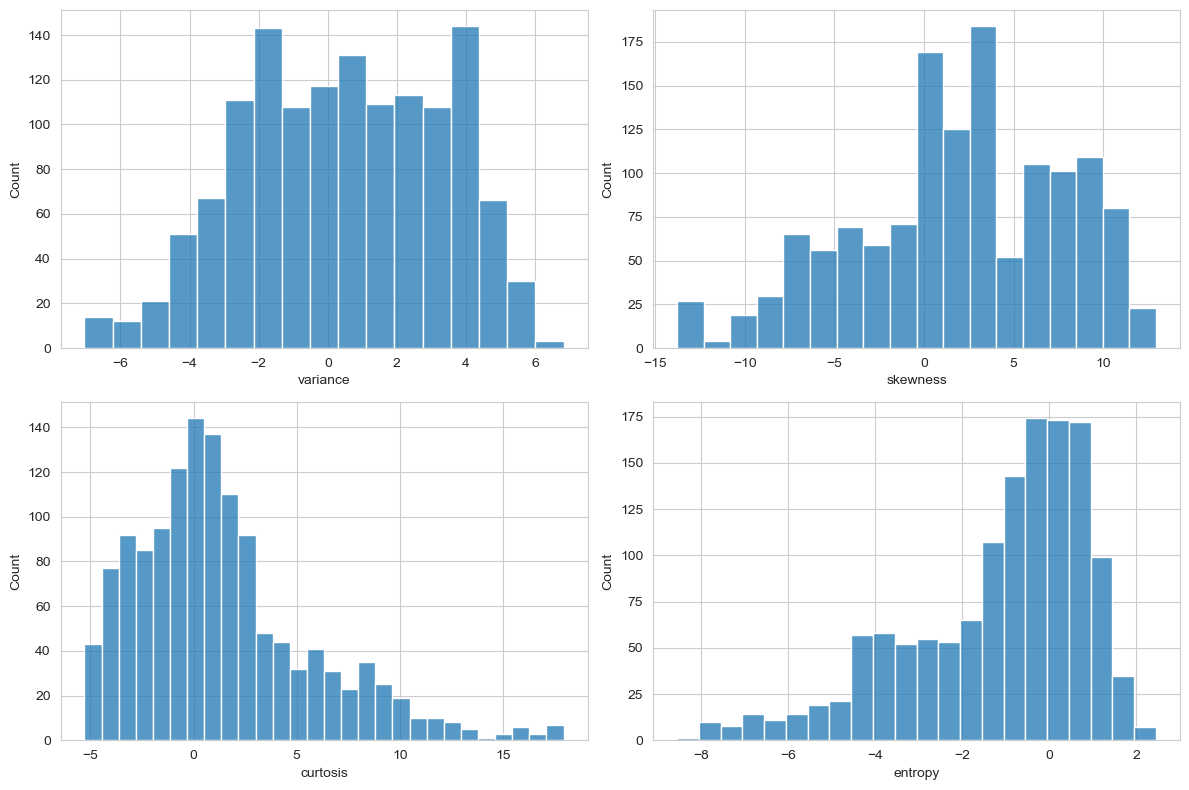

In [47]:
display(Markdown("## Feature Distributions"))

fig , axes = plt.subplots(2,2 , figsize=(12 , 8))
sns.histplot(data = data , x = "variance", ax = axes[0,0])
sns.histplot(data = data , x = "skewness", ax = axes[0,1])
sns.histplot(data = data , x = "curtosis", ax = axes[1,0])
sns.histplot(data = data , x = "entropy" , ax = axes[1,1])

plt.tight_layout()

fig.savefig(
    "../images/feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



## Feature Relationships

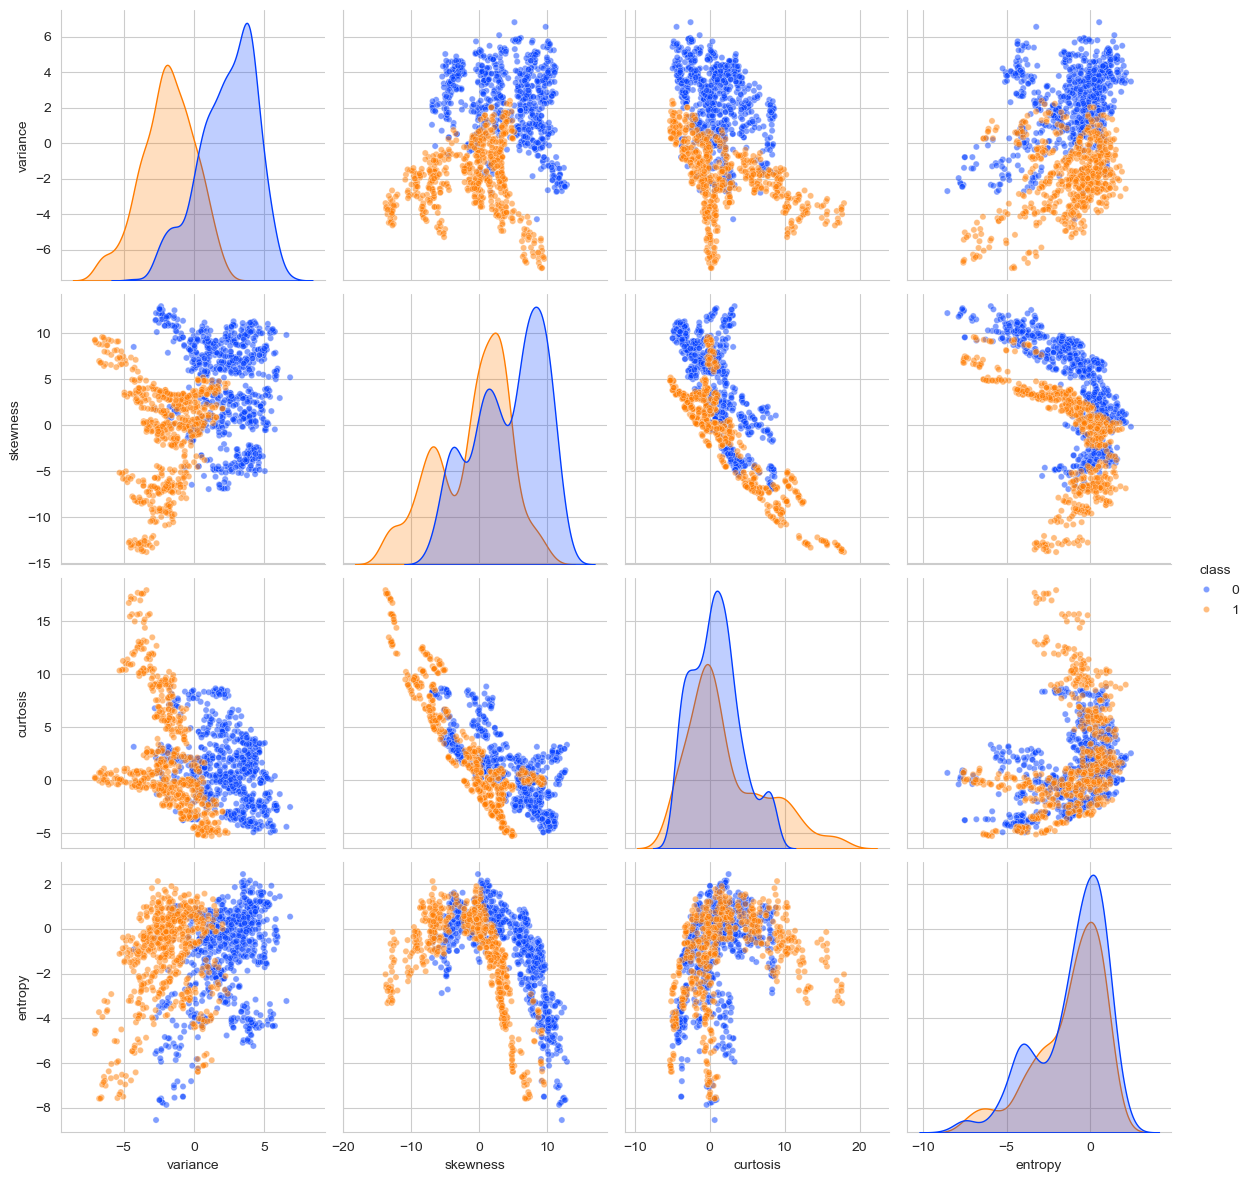

In [48]:
display(Markdown("## Feature Relationships"))
sns.set_style("whitegrid")
pairwiseplot =  sns.pairplot(
    data = data,
    vars =data.columns.drop("class"),
    hue = "class",
    palette="bright",
    plot_kws = {
        "alpha" : 0.5 ,
        "s":20,
        
            },
    height = 3,


)

pairwiseplot.savefig(
    "../images/pair_plot_hist.png",
    dpi = 300,
    bbox_inches="tight"
)
plt.show()



# Correlation Matrix

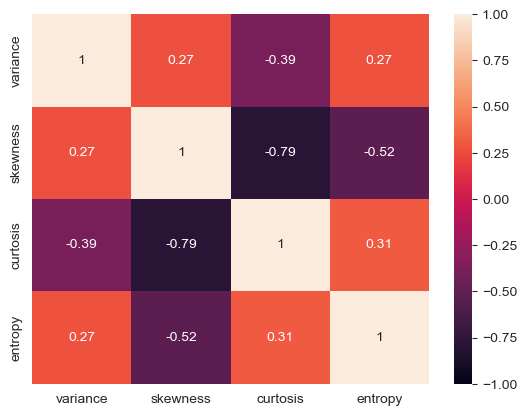

In [49]:
display(Markdown("# Correlation Matrix"))
exc = data.drop(columns=["class"])
_ = sns.heatmap(
    exc.corr(),
    vmin = -1,
    vmax = 1,
    annot = True
    )
plt.show()

# Outlier Exploration

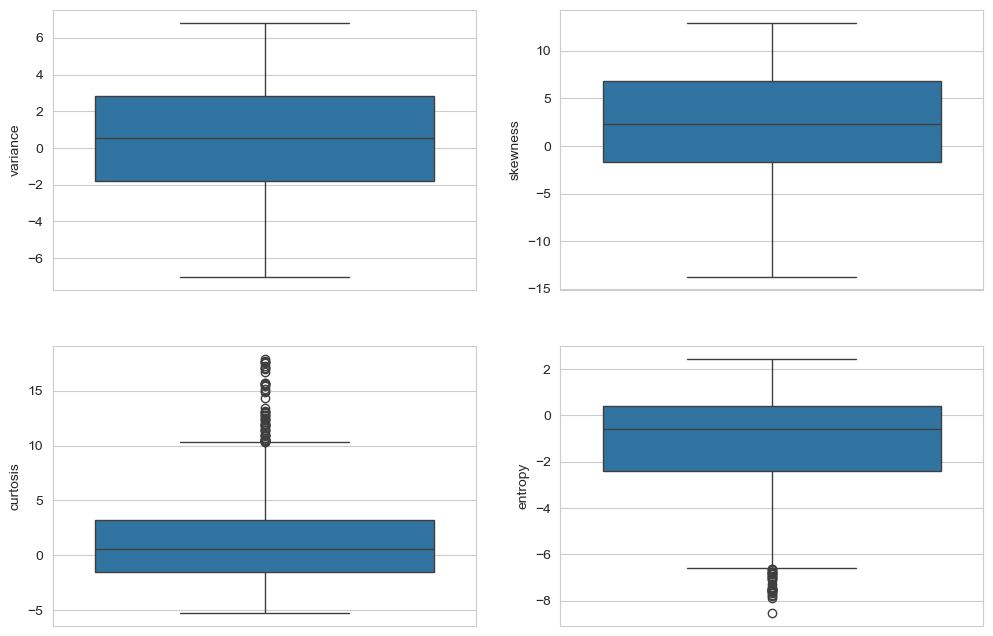

In [50]:
display(Markdown("# Outlier Exploration"))

fig1 , axes  = plt.subplots( 2, 2 ,figsize = (12,8))
sns.boxplot(data = data , y = "variance",ax = axes[0,0])
sns.boxplot(data = data , y = "skewness",ax = axes[0,1])
sns.boxplot(data = data , y = "curtosis",ax = axes[1,0])
sns.boxplot(data = data , y = "entropy" ,ax = axes[1,1])

fig1.savefig(
    "../images/possible_outliers.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()


In [51]:
x = data["curtosis"]

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

mask = (
    (x < Q1 - 1.5 * IQR) |
    (x > Q3 + 1.5 * IQR)
)

data.loc[mask, "class"].value_counts()

class
1    59
Name: count, dtype: int64

In [52]:
z = data["entropy"]
Q1 =  z.quantile(0.25)
Q3 =  z.quantile(0.75)
IQR = Q3 - Q1 

mask = (
    (z < Q1 - IQR * 1.5 ) |
    (z > Q3 + IQR * 1.5 )
)

data.loc[mask , "class"].value_counts()


class
1    17
0    15
Name: count, dtype: int64


## Conclusions


1. First we imported the txt file and assigned the columns [variance, skewness, curtosis, entropy, class] to the data.

2. Data shape revealed that we had 1372 samples and 4 features (columns) and 1 target, with 24 of the samples being duplicates, which we later removed and kept the first occurrence to avoid a train test split having the same data.

3. Description of the data revealed the data is not scaled and with std ranging from 2.1 to 5.88, which is really important when training our KNN model, since a KNN model is distance-based and features with large numerical values can dominate regardless of information, so standardization will transform the data into a mean equal to 0 and standard deviation equal to 1

# EDA

1. The features exhibit different distribution shapes with skewness being left-tailed and curtosis being right-tailed, but it also shows the shape of the distribution being irregular, since the models I am going to use don't need the data to be transformed into a normal distribution, but were still going to standardize the data.

2. Moving on to a pair plot, we can see that some features show clear relationships with each other and some pairs have a good separation with respect to the class. The linear correlations are  partly supported by the correlation matrix below, which ranges from no correlation to highly correlated features may contain redundant information and may impact model behaviour, but it doesn't tell us everything, since we can see from the pair plots that some features have a non-linear relationship with each other while being highly correlated.

3. Regarding the KDE Curves on the diagonal, we can see the distribution of the features by themselves. Some of the features have a good separation of classes, but some don't. For example, variance has good separation, which shows us univariate class separation, while "entropy" shows substantial overlap between classes.

4. Using a box plot, I investigated if the data contained possible outliers and found out that curtosis and entropy have possible outlier samples. However, after further investigation, I found out that all the curtosis "outliers" belonged to the forged class, which might indicate that these forged banknotes exhibit such data rather than being erroneous.
Regarding the entropy feature, I couldn't come up with a concrete hypothesis since the data is mixed, having almost a 50/50 split, but it doesn't mean that this data should be eliminated from our dataset, since the features/samples  can still contain useful information when considered together with other features.